In [ ]:
#Загрузка данных
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jutrera/stanford-car-dataset-by-classes-folder")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stanford-car-dataset-by-classes-folder' dataset.
Path to dataset files: /kaggle/input/stanford-car-dataset-by-classes-folder


# **Выборка данных**

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0

# Путь к папке (замените на ваш фактический путь)
PATH = '/kaggle/input/stanford-car-dataset-by-classes-folder'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Загрузка обучающей выборки
train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Загрузка проверочной выборки
val_ds = tf.keras.utils.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 16185 files belonging to 1 classes.
Using 12948 files for training.
Found 16185 files belonging to 1 classes.
Using 3237 files for validation.


# **Обработка данных**

In [ ]:
# Слой аугментации данных
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Загружаем EfficientNetB0 (предобученную на ImageNet)
# Она мощнее MobileNet и часто дает лучший результат
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False  # Замораживаем веса

# Собираем конструктор
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(train_ds.class_names), activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# **Обучение "шапки" модели**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping


# Этап 1: Разогрев
print("--- Начало обучения головы ---")
history = model.fit(train_ds, epochs=1, validation_data=val_ds)

# Этап 2: Fine-tuning
print("--- Тонкая настройка всей сети ---")
base_model.trainable = True # Размораживаем всё

# Важно: используем ОЧЕНЬ маленький шаг обучения, чтобы не "сломать" веса
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    epochs=1,
    validation_data=val_ds,
    verbose=1,

)

--- Начало обучения головы ---
405/405 ━━━━━━━━━━━━━━━━━━━━ 163s 402ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
--- Тонкая настройка всей сети ---
405/405 ━━━━━━━━━━━━━━━━━━━━ 190s 377ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


# **Проверка на валидационных данных и вывод графиков обучения**

102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 110ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Итоговая точность на проверочной выборке: 100.00%


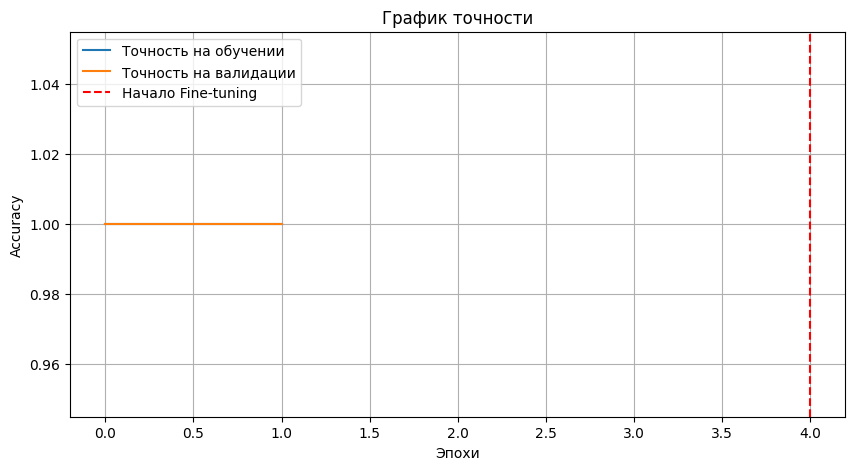

In [ ]:
# 1. Финальная проверка на валидационном сете
loss, accuracy = model.evaluate(val_ds)
print(f"Итоговая точность на проверочной выборке: {accuracy*100:.2f}%")

# 2. Построение графиков
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(10, 5))
plt.plot(acc, label='Точность на обучении')
plt.plot(val_acc, label='Точность на валидации')
plt.axvline(x=4, color='r', linestyle='--', label='Начало Fine-tuning') # Отметка смены этапа
plt.title('График точности')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()